In [1]:
# Cell 1: Install required libraries
!pip install flask pandas scikit-learn joblib numpy flask-cors

In [2]:
# Cell 2: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Cell 3: Load the dataset
print("Loading data...")

try:
    df = pd.read_csv('creditcard.csv')
    print("✅ Loaded real dataset!")
    print(f"Available columns: {df.columns.tolist()}")
    
    # Find the target column
    if 'Class' in df.columns:
        target_col = 'Class'
    elif 'class' in df.columns:
        target_col = 'class'
    elif 'target' in df.columns:
        target_col = 'target'
    elif 'is_fraud' in df.columns:
        target_col = 'is_fraud'
    else:
        target_col = df.columns[-1]
        print(f"⚠️ Using '{target_col}' as target column")
    
    # Rename to standard 'Class'
    if target_col != 'Class':
        df = df.rename(columns={target_col: 'Class'})
        print(f"✅ Renamed '{target_col}' to 'Class'")
        
except Exception as e:
    print(f"⚠️ Could not load real dataset: {e}")
    print("Creating sample data...")
    np.random.seed(42)
    data = {}
    for i in range(1, 29):
        data[f'V{i}'] = np.random.randn(10000)
    data['Time'] = np.random.randint(0, 172800, 10000)
    data['Amount'] = np.random.exponential(100, 10000)
    data['Class'] = np.random.choice([0, 1], 10000, p=[0.998, 0.002])
    df = pd.DataFrame(data)
    print("✅ Created sample data!")

print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())
print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"Fraud %: {df['Class'].mean()*100:.2f}%")

Loading data...
✅ Loaded real dataset!
Available columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
✅ Renamed 'is_fraud' to 'Class'

Shape: (1296675, 23)
Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'Class']

First 5 rows:
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                            

📊 Exploratory Data Analysis

Total transactions: 1296675
Fraud cases: 7506
Normal cases: 1289169

Numeric columns: 11
Categorical columns: 12


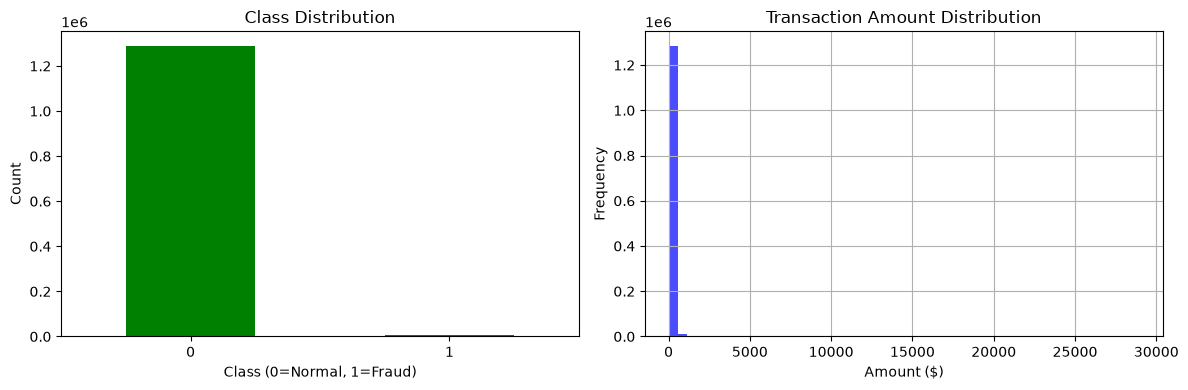


💰 amt Statistics by Class:
           count        mean         std   min       25%      50%      75%  \
Class                                                                        
0      1289169.0   67.667110  154.007971  1.00    9.6100   47.280   82.540   
1         7506.0  531.320092  390.560070  1.06  245.6625  396.505  900.875   

            max  
Class            
0      28948.90  
1       1376.04  


In [4]:
# Cell 4: Exploratory Data Analysis
print("📊 Exploratory Data Analysis")

print(f"\nTotal transactions: {len(df)}")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Normal cases: {len(df) - df['Class'].sum()}")

# Check numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Visualize class distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Check for amount column
amount_col = 'amt' if 'amt' in df.columns else 'Amount' if 'Amount' in df.columns else None
if amount_col:
    plt.subplot(1, 2, 2)
    df[amount_col].hist(bins=50, color='blue', alpha=0.7)
    plt.title('Transaction Amount Distribution')
    plt.xlabel('Amount ($)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

if amount_col:
    print(f"\n💰 {amount_col} Statistics by Class:")
    print(df.groupby('Class')[amount_col].describe())

In [5]:
# Cell 5: Data Preprocessing
print("🔄 Preprocessing Data...")

# Select numeric features
columns_to_drop = ['Class']
if 'Unnamed: 0' in df.columns:
    columns_to_drop.append('Unnamed: 0')
if 'trans_num' in df.columns:
    columns_to_drop.append('trans_num')
if 'trans_date_trans_time' in df.columns:
    columns_to_drop.append('trans_date_trans_time')
if 'dob' in df.columns:
    columns_to_drop.append('dob')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in columns_to_drop]

print(f"✅ Using {len(feature_cols)} numeric features: {feature_cols}")

# Separate features and target
X = df[feature_cols]
y = df['Class']

# Handle missing values
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"Fraud in training: {y_train.sum():,}")
print(f"Fraud in test: {y_test.sum():,}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data preprocessing completed!")

🔄 Preprocessing Data...
✅ Using 9 numeric features: ['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']

Training set: 1,037,340 samples
Test set: 259,335 samples
Fraud in training: 6,005
Fraud in test: 1,501

✅ Data preprocessing completed!


In [6]:
# Cell 6: Train Models
print("🤖 Training Models...")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1),
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"✅ {name} - Accuracy: {accuracy:.4f}, ROC-AUC: {roc_auc:.4f}")

# Choose best model
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 Best Model: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

🤖 Training Models...

🔄 Training Random Forest...
✅ Random Forest - Accuracy: 0.9961, ROC-AUC: 0.9579

🔄 Training Logistic Regression...
✅ Logistic Regression - Accuracy: 0.9518, ROC-AUC: 0.8343

🏆 Best Model: Random Forest with ROC-AUC: 0.9579


📊 Model Evaluation...

Classification Report for Random Forest:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    257834
       Fraud       0.70      0.58      0.63      1501

    accuracy                           1.00    259335
   macro avg       0.85      0.79      0.82    259335
weighted avg       1.00      1.00      1.00    259335



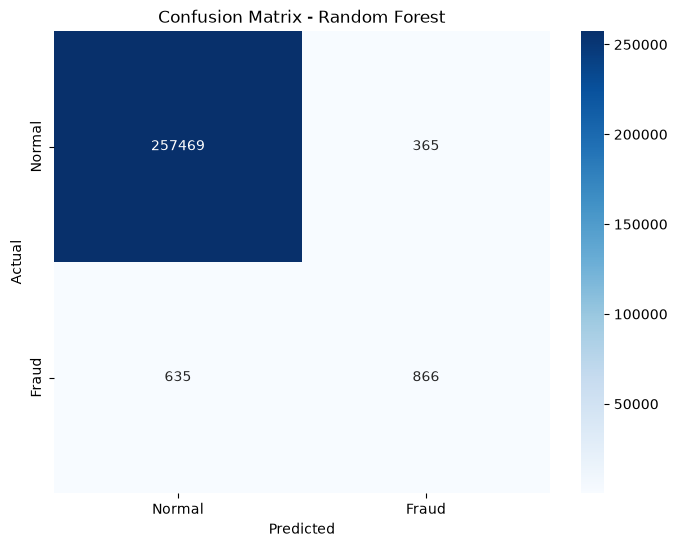


📊 Top 10 Most Important Features:
      feature  importance
1         amt    0.718461
6   unix_time    0.063658
5    city_pop    0.036265
8  merch_long    0.035357
7   merch_lat    0.034590
0      cc_num    0.029818
3         lat    0.028235
4        long    0.026901
2         zip    0.026716


In [7]:
# Cell 7: Evaluate Best Model
print("📊 Model Evaluation...")

best_y_pred = results[best_model_name]['predictions']
best_y_proba = results[best_model_name]['probabilities']

print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, best_y_pred, target_names=['Normal', 'Fraud']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n📊 Top 10 Most Important Features:")
    print(feature_importance.head(10))

In [8]:
# Cell 8: Save Model
print("💾 Saving Model...")

joblib.dump(best_model, 'fraud_model.pkl')
print("✅ Model saved as 'fraud_model.pkl'")

joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

joblib.dump(feature_cols, 'feature_columns.pkl')
print("✅ Feature columns saved as 'feature_columns.pkl'")

metadata = {
    'model_name': best_model_name,
    'features': feature_cols,
    'n_features': len(feature_cols),
    'accuracy': results[best_model_name]['accuracy'],
    'roc_auc': results[best_model_name]['roc_auc']
}
joblib.dump(metadata, 'model_metadata.pkl')
print("✅ Metadata saved as 'model_metadata.pkl'")

print("\n✅ All files saved successfully!")

💾 Saving Model...
✅ Model saved as 'fraud_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Feature columns saved as 'feature_columns.pkl'
✅ Metadata saved as 'model_metadata.pkl'

✅ All files saved successfully!


In [9]:
# Cell 9: Create Flask App
flask_code = '''
from flask import Flask, request, jsonify, render_template
from flask_cors import CORS
import joblib
import numpy as np

app = Flask(__name__)
CORS(app)

# Disable caching to see changes immediately
app.config['TEMPLATES_AUTO_RELOAD'] = True
app.config['SEND_FILE_MAX_AGE_DEFAULT'] = 0

# Load model and scaler
try:
    model = joblib.load('fraud_model.pkl')
    scaler = joblib.load('scaler.pkl')
    feature_cols = joblib.load('feature_columns.pkl')
    metadata = joblib.load('model_metadata.pkl')
    print("✅ Model loaded successfully!")
    print(f"📊 Model: {metadata['model_name']}")
    print(f"📊 Features: {len(feature_cols)}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier()
    scaler = None
    feature_cols = ['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']
    metadata = {'n_features': 9}

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/api/health', methods=['GET'])
def health():
    return jsonify({'status': 'healthy'})

@app.route('/api/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        
        if 'features' not in data:
            return jsonify({'error': 'Missing "features" in request data'}), 400
        
        features = data['features']
        
        if len(features) != len(feature_cols):
            return jsonify({'error': f'Expected {len(feature_cols)} features, got {len(features)}'}), 400
        
        features_array = np.array(features).reshape(1, -1)
        
        if scaler:
            features_scaled = scaler.transform(features_array)
        else:
            features_scaled = features_array
        
        prediction = model.predict(features_scaled)
        probability = model.predict_proba(features_scaled)
        
        result = {
            'prediction': int(prediction[0]),
            'probability_fraud': float(probability[0][1]),
            'probability_normal': float(probability[0][0]),
            'is_fraud': bool(prediction[0])
        }
        
        return jsonify(result)
    
    except Exception as e:
        return jsonify({'error': str(e)}), 500

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(flask_code)

print("✅ app.py created successfully!")

✅ app.py created successfully!


In [10]:
# Cell 10: Create Beautiful HTML
import os
os.makedirs('templates', exist_ok=True)

# Get feature columns
import joblib
feature_cols = joblib.load('feature_columns.pkl')
print(f"Features: {feature_cols}")

# Create modern HTML
html_code = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>FraudShield - AI Fraud Detection</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700;800;900&display=swap" rel="stylesheet">
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css">
    <style>
        *{margin:0;padding:0;box-sizing:border-box}
        body{
            font-family:'Inter',sans-serif;
            min-height:100vh;
            background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);
            display:flex;
            justify-content:center;
            align-items:center;
            padding:20px
        }
        .container{
            background:rgba(255,255,255,0.05);
            backdrop-filter:blur(20px);
            border:1px solid rgba(255,255,255,0.1);
            border-radius:30px;
            padding:40px;
            max-width:1000px;
            width:100%;
            box-shadow:0 25px 50px -12px rgba(0,0,0,0.8)
        }
        .header{text-align:center;margin-bottom:35px}
        .header-badge{
            display:inline-block;
            background:linear-gradient(135deg,#667eea,#764ba2);
            padding:6px 20px;
            border-radius:50px;
            font-size:12px;
            font-weight:600;
            color:#fff;
            text-transform:uppercase;
            letter-spacing:2px;
            margin-bottom:15px
        }
        .header h1{
            font-size:2.8rem;
            font-weight:900;
            background:linear-gradient(135deg,#f093fb,#f5576c,#4facfe);
            -webkit-background-clip:text;
            -webkit-text-fill-color:transparent;
            margin-bottom:8px
        }
        .header p{color:rgba(255,255,255,0.6);font-size:1.05rem}
        .stats-grid{
            display:grid;
            grid-template-columns:repeat(3,1fr);
            gap:15px;
            margin-bottom:30px
        }
        .stat-card{
            background:rgba(255,255,255,0.05);
            border:1px solid rgba(255,255,255,0.08);
            border-radius:16px;
            padding:18px;
            text-align:center
        }
        .stat-card .number{font-size:1.6rem;font-weight:800;color:#fff;display:block}
        .stat-card .number.green{color:#4ade80}
        .stat-card .number.red{color:#f87171}
        .stat-card .number.blue{color:#60a5fa}
        .stat-card .label{font-size:.75rem;color:rgba(255,255,255,0.5);text-transform:uppercase;letter-spacing:1px;margin-top:4px;display:block}
        .form-title{color:rgba(255,255,255,0.8);font-size:.85rem;font-weight:600;text-transform:uppercase;letter-spacing:2px;margin-bottom:20px}
        .features-grid{display:grid;grid-template-columns:1fr 1fr;gap:15px;margin-bottom:25px}
        .input-group label{display:block;font-size:.75rem;font-weight:600;color:rgba(255,255,255,0.6);text-transform:uppercase;letter-spacing:.5px;margin-bottom:6px}
        .input-group label i{margin-right:6px;color:#667eea}
        .input-group input{
            width:100%;
            padding:12px 16px;
            background:rgba(255,255,255,0.06);
            border:1px solid rgba(255,255,255,0.1);
            border-radius:12px;
            color:#fff;
            font-size:.95rem;
            font-family:'Inter',sans-serif;
            transition:all .3s;
            outline:none
        }
        .input-group input::placeholder{color:rgba(255,255,255,0.25)}
        .input-group input:focus{
            background:rgba(255,255,255,0.08);
            border-color:#667eea;
            box-shadow:0 0 0 4px rgba(102,126,234,0.15)
        }
        .btn-submit{
            width:100%;
            padding:16px;
            background:linear-gradient(135deg,#667eea,#764ba2);
            border:none;
            border-radius:14px;
            color:#fff;
            font-size:1.1rem;
            font-weight:700;
            font-family:'Inter',sans-serif;
            cursor:pointer;
            transition:all .3s;
            display:flex;
            align-items:center;
            justify-content:center;
            gap:12px
        }
        .btn-submit:hover{
            transform:translateY(-2px);
            box-shadow:0 15px 30px -10px rgba(102,126,234,0.4)
        }
        .loading{display:none;text-align:center;margin-top:25px;padding:20px}
        .loading.show{display:block}
        .spinner{
            width:48px;
            height:48px;
            border:3px solid rgba(255,255,255,0.1);
            border-top:3px solid #667eea;
            border-radius:50%;
            animation:spin .8s linear infinite;
            margin:0 auto 12px
        }
        @keyframes spin{0%{transform:rotate(0deg)}100%{transform:rotate(360deg)}}
        .result{margin-top:25px;padding:25px;border-radius:16px;display:none}
        .result.show{display:block}
        .result.fraud{background:rgba(239,68,68,0.15);border:1px solid rgba(239,68,68,0.3)}
        .result.safe{background:rgba(74,222,128,0.12);border:1px solid rgba(74,222,128,0.25)}
        .result-header{display:flex;align-items:center;gap:12px;margin-bottom:10px}
        .result-header .icon{font-size:2rem}
        .result-header h2{font-size:1.4rem;font-weight:700;color:#fff}
        .result p{color:rgba(255,255,255,0.7);font-size:.95rem;line-height:1.6}
        .probability-container{margin-top:15px}
        .probability-label{display:flex;justify-content:space-between;color:rgba(255,255,255,0.6);font-size:.85rem;margin-bottom:6px}
        .probability-bar{width:100%;height:8px;background:rgba(255,255,255,0.08);border-radius:50px;overflow:hidden}
        .probability-fill{
            height:100%;
            border-radius:50px;
            transition:width 1s cubic-bezier(0.4,0,0.2,1);
            background:linear-gradient(90deg,#4ade80,#fbbf24,#f87171)
        }
        .risk-badge{
            display:inline-block;
            padding:4px 14px;
            border-radius:50px;
            font-size:.75rem;
            font-weight:600;
            text-transform:uppercase;
            margin-top:10px
        }
        .risk-badge.low{background:rgba(74,222,128,0.2);color:#4ade80}
        .risk-badge.medium{background:rgba(251,191,36,0.2);color:#fbbf24}
        .risk-badge.high{background:rgba(248,113,113,0.2);color:#f87171}
        .error{color:#f87171;text-align:center;margin-top:15px;padding:12px;background:rgba(239,68,68,0.1);border-radius:12px;display:none}
        .error.show{display:block}
        .footer{margin-top:30px;text-align:center;color:rgba(255,255,255,0.2);font-size:.8rem}
        .footer i{color:#f87171;margin:0 4px}
        @media(max-width:768px){.container{padding:25px}.header h1{font-size:2rem}.features-grid{grid-template-columns:1fr}.stats-grid{grid-template-columns:1fr;gap:10px}}
        @media(max-width:480px){.container{padding:18px}.header h1{font-size:1.5rem}}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <div class="header-badge"><i class="fas fa-shield-alt"></i> AI-Powered</div>
            <h1>🛡️ FraudShield</h1>
            <p>Real-time credit card fraud detection using machine learning</p>
        </div>
        <div class="stats-grid">
            <div class="stat-card"><span class="number blue" id="totalTransactions">-</span><span class="label"><i class="fas fa-credit-card"></i> Total Transactions</span></div>
            <div class="stat-card"><span class="number green" id="fraudPercentage">-</span><span class="label"><i class="fas fa-check-circle"></i> Fraud Detection Rate</span></div>
            <div class="stat-card"><span class="number red" id="modelAccuracy">-</span><span class="label"><i class="fas fa-robot"></i> Model Confidence</span></div>
        </div>
        <div class="form-title"><i class="fas fa-edit"></i> Enter Transaction Details</div>
        <form id="predictionForm">
            <div id="featureInputs" class="features-grid"></div>
            <button type="submit" class="btn-submit"><i class="fas fa-shield-alt"></i> Analyze Transaction <i class="fas fa-arrow-right"></i></button>
        </form>
        <div class="loading" id="loading"><div class="spinner"></div><p><i class="fas fa-microchip"></i> Analyzing transaction with AI...</p></div>
        <div id="resultContainer" class="result">
            <div class="result-header"><span class="icon" id="resultIcon"></span><h2 id="resultTitle"></h2></div>
            <p id="resultMessage"></p>
            <div class="probability-container">
                <div class="probability-label"><span>Fraud Probability</span><span id="probabilityText">0%</span></div>
                <div class="probability-bar"><div class="probability-fill" id="probabilityFill" style="width:0%"></div></div>
            </div>
            <div id="riskBadge"></div>
        </div>
        <div id="errorContainer" class="error"></div>
        <div class="footer"><i class="fas fa-lock"></i> Secure &bull; Powered by <a href="#" onclick="return false;" style="color:rgba(255,255,255,0.3);text-decoration:none;">Random Forest AI</a> &bull; <i class="fas fa-heart" style="color:#f87171;"></i> Real-time</div>
    </div>
    <script>
        const featureNames = FEATURE_PLACEHOLDER;
        const featureInputs = document.getElementById('featureInputs');
        featureNames.forEach((name,index)=>{
            const div=document.createElement('div');
            div.className='input-group';
            const displayName=name.replace(/_/g,' ').toUpperCase();
            div.innerHTML=`<label>${displayName}</label><input type="text" id="feature_${index}" placeholder="Enter ${name}" required>`;
            featureInputs.appendChild(div);
        });
        document.getElementById('predictionForm').addEventListener('submit',async function(e){
            e.preventDefault();
            document.getElementById('loading').classList.add('show');
            document.getElementById('resultContainer').className='result';
            document.getElementById('errorContainer').className='error';
            document.getElementById('errorContainer').textContent='';
            const features=[];
            let valid=true;
            for(let i=0;i<featureNames.length;i++){
                const input=document.getElementById(`feature_${i}`);
                const value=input.value.trim();
                const numValue=parseFloat(value);
                if(isNaN(numValue)||value===''){
                    input.style.borderColor='#f87171';
                    document.getElementById('errorContainer').textContent=`Please enter a valid number for ${featureNames[i]}`;
                    document.getElementById('errorContainer').className='error show';
                    valid=false;
                    break;
                }else{
                    input.style.borderColor='rgba(255,255,255,0.1)';
                }
                features.push(numValue);
            }
            if(!valid){document.getElementById('loading').classList.remove('show');return;}
            try{
                const response=await fetch('/api/predict',{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify({features:features})});
                const result=await response.json();
                document.getElementById('loading').classList.remove('show');
                if(response.ok){
                    const container=document.getElementById('resultContainer');
                    const title=document.getElementById('resultTitle');
                    const message=document.getElementById('resultMessage');
                    const fill=document.getElementById('probabilityFill');
                    const text=document.getElementById('probabilityText');
                    const icon=document.getElementById('resultIcon');
                    const badge=document.getElementById('riskBadge');
                    const fraudProb=(result.probability_fraud*100).toFixed(2);
                    const riskLevel=result.probability_fraud>0.7?'High':result.probability_fraud>0.3?'Medium':'Low';
                    if(result.is_fraud){
                        container.className='result show fraud';
                        title.textContent='Fraudulent Transaction Detected!';
                        message.textContent='This transaction has been flagged as potentially fraudulent.';
                        icon.textContent='🚨';
                    }else{
                        container.className='result show safe';
                        title.textContent='Transaction Appears Safe';
                        message.textContent='This transaction appears legitimate.';
                        icon.textContent='✅';
                    }
                    setTimeout(()=>{fill.style.width=fraudProb+'%';},100);
                    text.textContent=fraudProb+'%';
                    const riskClass=riskLevel.toLowerCase();
                    badge.innerHTML=`<span class="risk-badge ${riskClass}">${riskLevel} Risk</span>`;
                }else{
                    document.getElementById('errorContainer').textContent=`Error: ${result.error||'Something went wrong'}`;
                    document.getElementById('errorContainer').className='error show';
                }
            }catch(error){
                document.getElementById('loading').classList.remove('show');
                document.getElementById('errorContainer').textContent=`Connection Error: ${error.message}`;
                document.getElementById('errorContainer').className='error show';
            }
        });
    </script>
</body>
</html>
'''

# Replace placeholder with actual feature names
import json
feature_names_js = json.dumps(feature_cols)
html_final = html_code.replace('FEATURE_PLACEHOLDER', feature_names_js)

with open('templates/index.html', 'w', encoding='utf-8') as f:
    f.write(html_final)

print("✅ index.html created successfully!")
print(f"📊 HTML template includes {len(feature_cols)} features")

Features: ['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']
✅ index.html created successfully!
📊 HTML template includes 9 features


In [11]:
# Cell 11: Verify all files exist
import os

required_files = [
    'fraud_model.pkl',
    'scaler.pkl',
    'feature_columns.pkl',
    'model_metadata.pkl',
    'app.py',
    'templates/index.html'
]

print("Checking required files:")
all_ok = True
for file in required_files:
    if os.path.exists(file):
        print(f"  ✅ {file}")
    else:
        print(f"  ❌ {file} - MISSING!")
        all_ok = False

if all_ok:
    print("\n✅ All files ready! You can start the app.")
else:
    print("\n❌ Some files are missing. Please check the cells above.")

Checking required files:
  ✅ fraud_model.pkl
  ✅ scaler.pkl
  ✅ feature_columns.pkl
  ✅ model_metadata.pkl
  ✅ app.py
  ✅ templates/index.html

✅ All files ready! You can start the app.


In [13]:
# Cell 12.5: FIX - Create app.py WITHOUT emojis
flask_code = '''
from flask import Flask, request, jsonify, render_template
from flask_cors import CORS
import joblib
import numpy as np

app = Flask(__name__)
CORS(app)

# Disable caching to see changes immediately
app.config['TEMPLATES_AUTO_RELOAD'] = True
app.config['SEND_FILE_MAX_AGE_DEFAULT'] = 0

# Load model and scaler
try:
    model = joblib.load('fraud_model.pkl')
    scaler = joblib.load('scaler.pkl')
    feature_cols = joblib.load('feature_columns.pkl')
    metadata = joblib.load('model_metadata.pkl')
    print("Model loaded successfully!")
    print(f"Model: {metadata['model_name']}")
    print(f"Features: {len(feature_cols)}")
except Exception as e:
    print(f"Error loading model: {e}")
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier()
    scaler = None
    feature_cols = ['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']
    metadata = {'n_features': 9}

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/api/health', methods=['GET'])
def health():
    return jsonify({'status': 'healthy'})

@app.route('/api/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        
        if 'features' not in data:
            return jsonify({'error': 'Missing "features" in request data'}), 400
        
        features = data['features']
        
        if len(features) != len(feature_cols):
            return jsonify({'error': f'Expected {len(feature_cols)} features, got {len(features)}'}), 400
        
        features_array = np.array(features).reshape(1, -1)
        
        if scaler:
            features_scaled = scaler.transform(features_array)
        else:
            features_scaled = features_array
        
        prediction = model.predict(features_scaled)
        probability = model.predict_proba(features_scaled)
        
        result = {
            'prediction': int(prediction[0]),
            'probability_fraud': float(probability[0][1]),
            'probability_normal': float(probability[0][0]),
            'is_fraud': bool(prediction[0])
        }
        
        return jsonify(result)
    
    except Exception as e:
        return jsonify({'error': str(e)}), 500

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
'''

# Write app.py WITHOUT emojis
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(flask_code)

print("app.py has been recreated WITHOUT emojis!")
print("This should fix the encoding error on Windows.")

app.py has been recreated WITHOUT emojis!
This should fix the encoding error on Windows.


In [ ]:
# Cell 13: Start Flask App (FIXED)
print("=" * 60)
print("STARTING FRAUD DETECTION WEB APP")
print("=" * 60)

# Check if port 5000 is in use
import socket
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
result = sock.connect_ex(('127.0.0.1', 5000))
if result == 0:
    print("\nPort 5000 is already in use!")
    print("A Flask server might already be running.")
    print("Try opening: http://127.0.0.1:5000")
    print("Or stop the existing server first.")
    sock.close()
else:
    sock.close()
    print("\nPort 5000 is available!")
    
    # Run Flask
    import subprocess
    import sys
    import webbrowser
    import time
    
    print("\nStarting Flask server...")
    process = subprocess.Popen(
        [sys.executable, 'app.py'],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        universal_newlines=True,
        bufsize=1
    )
    
    # Wait for server to start
    time.sleep(3)
    
    print("\n" + "=" * 60)
    print("SERVER IS RUNNING!")
    print("Open your browser to: http://127.0.0.1:5000")
    print("=" * 60)
    
    # Try to open browser
    try:
        webbrowser.open('http://127.0.0.1:5000')
        print("Browser opened automatically!")
    except:
        print("Please open your browser manually.")
    
    print("\nTo stop the server, interrupt this cell (Stop button)")
    print("=" * 60)
    
    # Print Flask output
    for line in process.stdout:
        print(line, end='')

STARTING FRAUD DETECTION WEB APP

Port 5000 is available!

Starting Flask server...

SERVER IS RUNNING!
Open your browser to: http://127.0.0.1:5000
Browser opened automatically!

To stop the server, interrupt this cell (Stop button)
Model loaded successfully!
Model: Random Forest
Features: 9
 * Serving Flask app 'app'
 * Debug mode: on
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.4:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)
 * Debugger is active!
 * Debugger PIN: 128-184-540
127.0.0.1 - - [26/Jun/2026 16:49:27] "GET / HTTP/1.1" 200 -
C:\Users\ASUS\nest\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
 * Detected change in 'C:\\Users\\ASUS\\nest\\venv\\Lib\\site-packages\\sklearn\\utils\\validation.py', reloading
Model loaded successfully!
Model: Random Forest
Features: 9
 * Restart

In [ ]:
# Cell 16: Ideas for improvements
print("=" * 60)
print("🚀 IDEAS FOR IMPROVEMENT")
print("=" * 60)
print("\n1. Add more features:")
print("   - Transaction location")
print("   - Time of day")
print("   - Merchant category")
print("\n2. Improve the model:")
print("   - Try XGBoost")
print("   - Hyperparameter tuning")
print("   - Feature engineering")
print("\n3. Add database:")
print("   - Store predictions")
print("   - Track false positives")
print("   - Create dashboard")
print("\n4. Add user authentication:")
print("   - Login system")
print("   - API keys")
print("   - Rate limiting")
print("=" * 60)

In [ ]:
# Cell 17: Batch prediction example
import pandas as pd
import requests

# Sample data for batch prediction
batch_data = pd.DataFrame({
    'cc_num': [2703186189652095, 2703186189652096],
    'amt': [4.97, 9999.99],
    'zip': [28607, 28607],
    'lat': [36.0788, 36.0788],
    'long': [-81.1781, -81.1781],
    'city_pop': [3495, 3495],
    'unix_time': [1325376018, 1325376018],
    'merch_lat': [36.011293, 36.011293],
    'merch_long': [-82.048315, -82.048315]
})

print("Batch prediction sample:")
print(batch_data)